# Example for bssunfold package with the SMT solver

- `unfold_smt()`: an unfolding method backed by an **SMT solver** (Satisfiability Modulo Theories) from the `z3-solver` package.

- This is a Python port of the Haskell/SBV `linearEqSolver` library. Instead of a numeric iteration, Z3 searches for an exact solution of the linear system `A x = b` using **exact rational arithmetic**.

- By default the solver minimizes the **L2 residual** `||A x - b||_2` (via the exact KKT characterization of the non-negative least-squares optimum) and then the **total fluence** `sum(x)`, which selects a deterministic solution for the usually underdetermined unfolding problem.

- If the L2 solve does not converge within its time budget, `unfold_smt` falls back to the **L1 residual** `||A x - b||_1` (also lexicographic, then minimal fluence).

## Setup

The full LANL response matrix has 60 energy bins. The Z3 optimizer performs exact (rational) arithmetic and a 60-bin system is far too large to solve within a reasonable time. We therefore build the detector on a **reduced 12-bin energy grid** obtained by subsampling `RF_LANL`; on this grid the SMT solver finds an *exact* solution in about a second.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL

# Subsample the LANL response matrix to a coarse 12-bin energy grid
E_full = np.array(RF_LANL['E_MeV'])
sel = np.unique(np.linspace(0, len(E_full) - 1, 12).astype(int))
E_MeV = E_full[sel]
sensitivities = {k: np.array(RF_LANL[k])[sel] for k in RF_LANL if k != 'E_MeV'}

det = Detector(sensitivities=sensitivities, E_MeV=E_MeV)
print(f'energy bins: {det.n_energy_bins}')
print(f'detectors: {len(det.detector_names)}')

energy bins: 12
detectors: 11


## Get effective readings for spectra

In [2]:
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
# The CSV and RF_LANL use different energy grids; get_effective_readings_for_spectra
# interpolates the reference spectrum onto the detector's reduced energy grid.
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV', 'ISO_ref_Cf252']])
readings

{'3in': 0.24026895352469882,
 '4in': 0.7382666818149126,
 '5in': 1.223082133816493,
 '6in': 2.0045216839033198,
 '8in': 2.3270375803220493,
 '9in': 2.422614104172094,
 '12in': 2.008136114958804,
 '18in': 0.7733912195010613,
 '9inPb': 2.3391986399600886,
 '12inPb': 2.069495408830662,
 '18inPb': 0.9198735144985909}

## SMT Unfolding (L2 objective)

Key parameters of `det.unfold_smt(...)`:

- `objective`: `'l2'` (default) or `'l1'`. The L2 objective finds the least-squares optimum exactly; the L1 objective is the historical lexicographic residual.
- `nonneg`: constrain the spectrum to `x >= 0` (default `True`).
- `timeout_ms`: solver time budget in milliseconds (default 10000).
- `random_state`: seed for the Z3 solver for reproducibility.
- `calculate_errors`: Monte-Carlo uncertainty on the unfolded spectrum.

In [3]:
# Unfold with the default L2 objective
result_smt_l2 = det.unfold_smt(
    readings=readings,
    objective='l2',
    nonneg=True,
    random_state=42,
)

print(f"Method: {result_smt_l2['method']}")
print(f"Objective: {result_smt_l2['objective']}")
print(f"Final residual norm: {result_smt_l2['residual_norm']:.6f}")
print(f"Total fluence: {result_smt_l2['spectrum'].sum():.4f}")

Method: SMT
Objective: l2
Final residual norm: 0.000000
Total fluence: 0.3566


In [4]:
print('Result keys:', sorted(result_smt_l2.keys()))
print('Spectrum (12 bins):')
print(result_smt_l2['spectrum'])

Result keys: ['doserates', 'effective_readings', 'energy', 'method', 'nonneg', 'objective', 'residual', 'residual_norm', 'spectrum', 'spectrum_absolute', 'timeout_ms']
Spectrum (12 bins):
[1.03336136e-10 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.39342292e-03
 8.22779219e-02 2.70885037e-01 0.00000000e+00 0.00000000e+00]


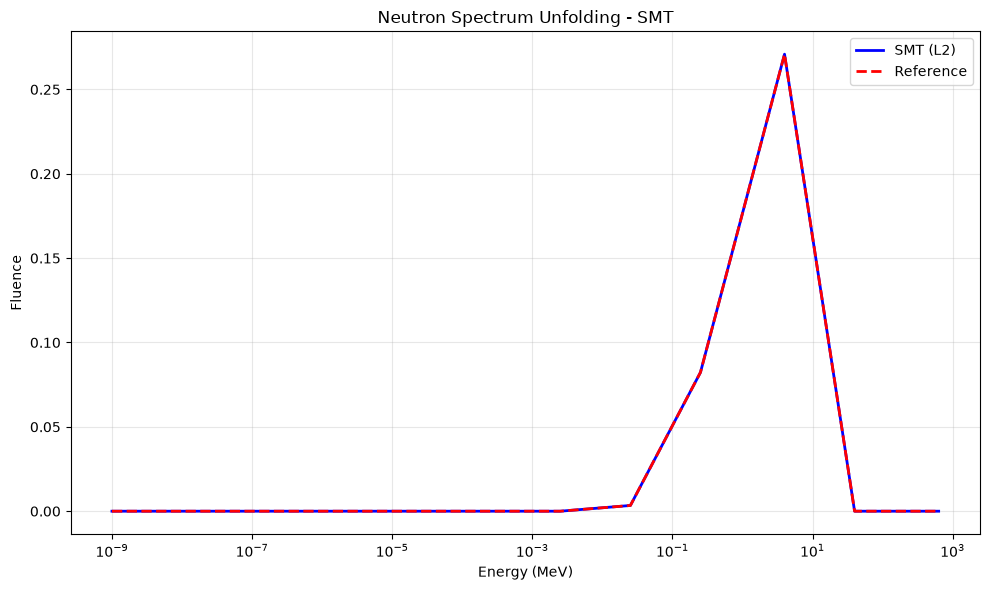

In [5]:
# Downsample the reference spectrum to the reduced energy grid (zero-safe)
E_ref = reference_spectrum['E_MeV'].values
R_ref = reference_spectrum['ISO_ref_Cf252'].values
R_c = np.interp(np.log10(result_smt_l2['energy']), np.log10(E_ref), R_ref)

# Plot SMT result
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(result_smt_l2['energy'], result_smt_l2['spectrum'], 'b-', linewidth=2, label='SMT (L2)')
ax.semilogx(result_smt_l2['energy'], R_c, 'r--', linewidth=2, label='Reference')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('Neutron Spectrum Unfolding - SMT')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SMT Unfolding with the L1 objective

The L1 objective minimizes `||A x - b||_1` and then the total fluence. On the coarse grid both objectives reach an exact solution (`residual_norm = 0`); the L1 path is also the automatic fallback if the L2 solve does not converge.

In [6]:
# Unfold with the L1 objective
result_smt_l1 = det.unfold_smt(
    readings=readings,
    objective='l1',
    nonneg=True,
    random_state=42,
)

print(f"Method: {result_smt_l1['method']}")
print(f"Objective: {result_smt_l1['objective']}")
print(f"Final residual norm: {result_smt_l1['residual_norm']:.6f}")
print(f"Total fluence: {result_smt_l1['spectrum'].sum():.4f}")

Method: SMT
Objective: l1
Final residual norm: 0.000000
Total fluence: 0.3566


## Comparison of Objectives

Let's compare the L2 and L1 solutions side by side.

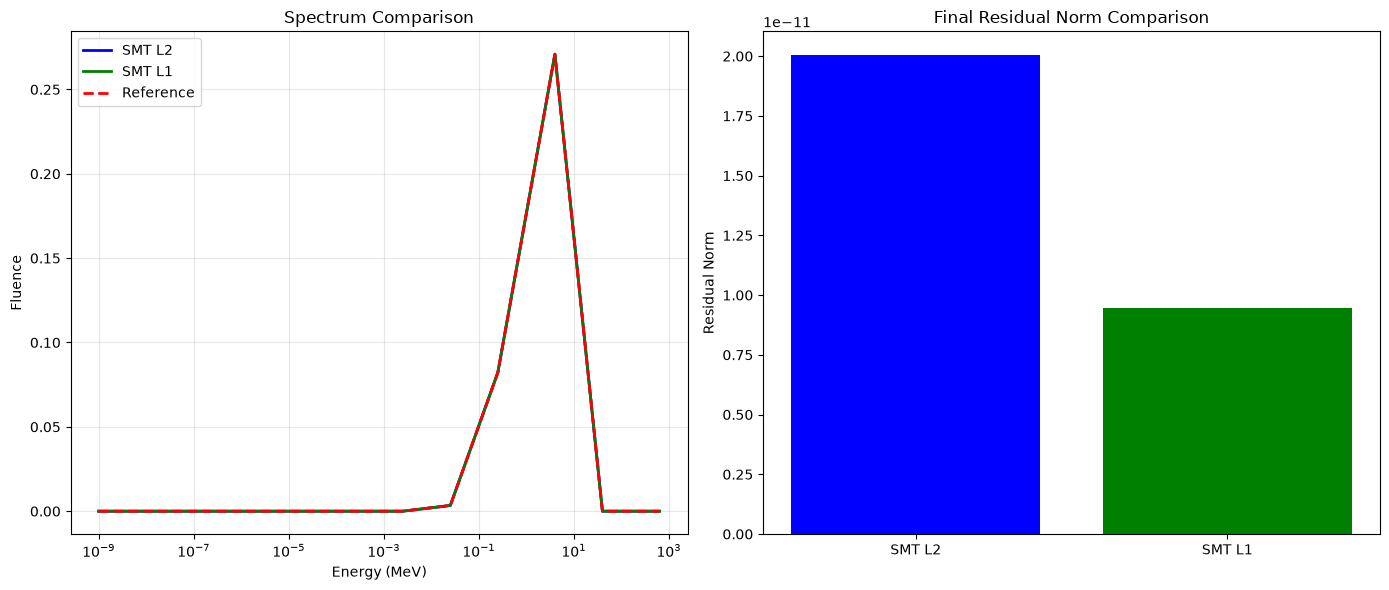

In [7]:
# Compare both objectives
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spectrum comparison
ax = axes[0]
ax.semilogx(result_smt_l2['energy'], result_smt_l2['spectrum'], 'b-', linewidth=2, label='SMT L2')
ax.semilogx(result_smt_l1['energy'], result_smt_l1['spectrum'], 'g-', linewidth=2, label='SMT L1')
ax.semilogx(result_smt_l2['energy'], R_c, 'r--', linewidth=2, label='Reference')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('Spectrum Comparison')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Residual comparison
ax = axes[1]
methods = ['SMT L2', 'SMT L1']
residuals = [
    result_smt_l2['residual_norm'],
    result_smt_l1['residual_norm'],
]
bars = ax.bar(methods, residuals, color=['blue', 'green'])
ax.set_ylabel('Residual Norm')
ax.set_title('Final Residual Norm Comparison')

plt.tight_layout()
plt.show()

## Uncertainty propagation (Monte Carlo)

`unfold_smt` supports Monte-Carlo uncertainty estimation, which is useful for such a discrete, exact solver: a small number of samples already gives a useful spread of the unfolded spectrum.

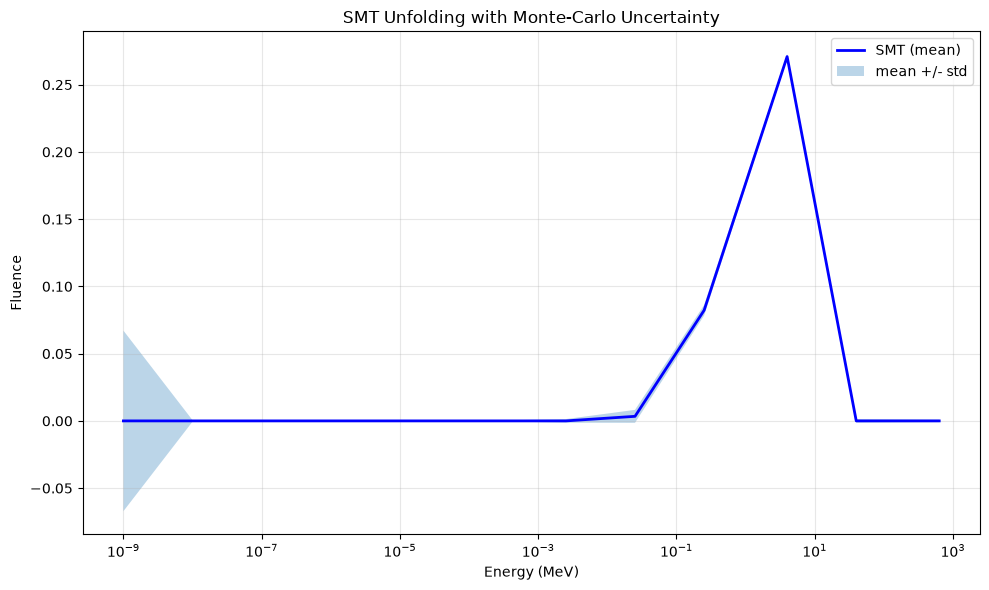

In [8]:
result_smt_mc = det.unfold_smt(
    readings=readings,
    objective='l2',
    calculate_errors=True,
    n_montecarlo=10,
    noise_level=0.01,
    random_state=42,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(result_smt_mc['energy'], result_smt_mc['spectrum'], 'b-', linewidth=2, label='SMT (mean)')
ax.fill_between(
    result_smt_mc['energy'],
    result_smt_mc['spectrum'] - result_smt_mc['spectrum_uncert_std'],
    result_smt_mc['spectrum'] + result_smt_mc['spectrum_uncert_std'],
    alpha=0.3, label='mean +/- std',
)
ax.set_xscale('log')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('SMT Unfolding with Monte-Carlo Uncertainty')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

**SMT advantages:**
- Exact solution in rational arithmetic (no iteration / no floating-point drift).
- Deterministic: the lexicographic objective (residual, then minimal fluence) selects a unique solution for underdetermined systems.
- On coarse grids the residual is exactly zero.

**Limitations:**
- Exact arithmetic is expensive: the full 60-bin LANL system is too large for Z3, so a reduced energy grid is required.
- No warm start / initial spectrum is used by the solver.

**When to use SMT:**
- When you want an exact, reproducible solution on a coarse grid.
- When the system is small enough for the Z3 optimizer (a few dozen variables).
- Use `objective='l2'` for the least-squares optimum and `objective='l1'` for the robust residual fallback.